# 06 — 多 Agent 与子图

**来源:** [菜鸟教程 — LangGraph 入门教程](https://www.runoob.com/ai-agent/langgraph-quick-start.html)

LangGraph 擅长协调多个专门化的 Agent 协同工作，也支持子图封装复用。

## 1. 多 Agent 协作（Supervisor 模式）

最常见的模式是 Supervisor（主从）模式：

```mermaid
graph TD
    Supervisor["Supervisor 主管"]
    Research["Research Agent\n信息收集"]
    Writing["Writing Agent\n内容创作"]
    Review["Review Agent\n质量审核"]
    Supervisor --> Research
    Research --> Supervisor
    Supervisor --> Writing
    Writing --> Supervisor
    Supervisor --> Review
    Review --> Supervisor
```

=== 多 Agent 协作完成 ===

[1] human: 请帮我写一篇关于 Python 装饰器的简短介绍文章...

[2] ai: RESEARCH...

[3] ai: ## Python 装饰器：让代码更优雅的“包装”艺术

装饰器（Decorator）是 Python 中一个强大且优雅的特性，它允许你在不修改函数本身代码的情况下，为函数添加额外的功能。通俗地说，装饰器就像一个“透明的包装盒”，你在外面贴上新的标签（增加功能），而盒子里的东西（原函数）保持不变。
...

[4] ai: FINISH...


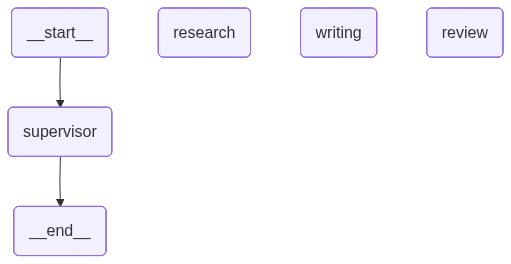

In [3]:
from dotenv import load_dotenv
load_dotenv()

import os
from langgraph.graph import StateGraph, MessagesState, START, END
from langchain_deepseek import ChatDeepSeek
from langchain_core.messages import SystemMessage, HumanMessage
from IPython.display import Image, display

# 初始化 LLM
llm = ChatDeepSeek(model='deepseek-v4-pro', temperature=0)


# 定义专家 Agent
def research_agent(state: MessagesState) -> dict:
    """研究 Agent：负责信息收集"""
    system = SystemMessage(content="你是一个专业的研究员，负责收集和整理信息。请简洁地总结关键信息。")
    response = llm.invoke([system] + state["messages"])
    return {"messages": [response]}

def writing_agent(state: MessagesState) -> dict:
    """写作 Agent：负责内容创作"""
    system = SystemMessage(content="你是一个专业的写作者，负责根据已有信息撰写内容。请保持内容清晰流畅。")
    response = llm.invoke([system] + state["messages"])
    return {"messages": [response]}

def review_agent(state: MessagesState) -> dict:
    """审校 Agent：负责质量控制"""
    system = SystemMessage(content="你是一个专业的编辑，负责审核和改进内容质量。请指出问题并给出改进建议。")
    response = llm.invoke([system] + state["messages"])
    return {"messages": [response]}

# 主管 Agent 决定流程
def supervisor_node(state: MessagesState) -> dict:
    """主管：协调各专家 Agent 的工作"""
    system = SystemMessage(content="""你是一个工作流主管。
根据任务进度决定下一步应该由哪个 Agent 处理。
分析对话历史，只返回以下之一：RESEARCH、WRITING、REVIEW、FINISH
- RESEARCH：需要收集更多信息
- WRITING：信息充足，可以开始写作
- REVIEW：写作完成，需要审核
- FINISH：任务已完成
""")
    response = llm.invoke([system] + state["messages"])
    return {"messages": [response]}

def route_by_supervisor(state: MessagesState) -> str:
    """根据主管决策路由"""
    last_msg = state["messages"][-1].content.strip().upper()

    if "RESEARCH" in last_msg:
        return "research"
    elif "WRITING" in last_msg:
        return "writing"
    elif "REVIEW" in last_msg:
        return "review"
    else:
        return END

# 构建多 Agent 图
builder = StateGraph(MessagesState)
builder.add_node("supervisor", supervisor_node)
builder.add_node("research", research_agent)
builder.add_node("writing", writing_agent)
builder.add_node("review", review_agent)

builder.add_edge(START, "supervisor")
builder.add_conditional_edges("supervisor", route_by_supervisor)

# 每个专家完成后返回主管
for agent in ["research", "writing", "review"]:
    builder.add_edge(agent, "supervisor")

graph = builder.compile()

# 测试多 Agent 协作
result = graph.invoke({
    "messages": [HumanMessage(content="请帮我写一篇关于 Python 装饰器的简短介绍文章")]
})

print("=== 多 Agent 协作完成 ===")
for i, msg in enumerate(result["messages"]):
    print(f"\n[{i+1}] {msg.type}: {msg.content[:150]}...")
display(Image(graph.get_graph().draw_mermaid_png()))

## 2. 子图（Subgraph）

将复杂子流程封装为子图，在主图中复用。子图自身就是一个编译好的 `StateGraph`，可以直接作为节点添加到主图中。

子图构建完成，主图包含: preprocessing → sub_workflow → postprocessing


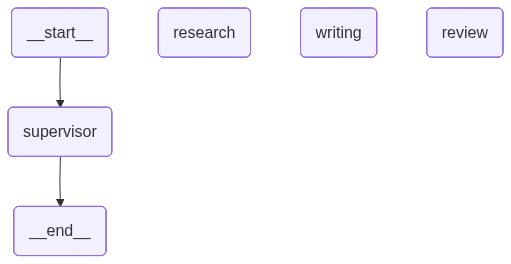

In [4]:
from langgraph.graph import StateGraph, MessagesState, START, END


def step1_node(state: MessagesState) -> dict:
    """子图第一步"""
    return {"messages": [{"role": "assistant", "content": "子图: 步骤1完成"}]}


def step2_node(state: MessagesState) -> dict:
    """子图第二步"""
    return {"messages": [{"role": "assistant", "content": "子图: 步骤2完成"}]}


# 构建子图
sub_builder = StateGraph(MessagesState)
sub_builder.add_node("step1", step1_node)
sub_builder.add_node("step2", step2_node)
sub_builder.add_edge(START, "step1")
sub_builder.add_edge("step1", "step2")
sub_builder.add_edge("step2", END)
sub_graph = sub_builder.compile()

# 在主图中使用子图
def preprocess_node(state: MessagesState) -> dict:
    """主图预处理节点"""
    return {"messages": [{"role": "assistant", "content": "预处理完成"}]}


def postprocess_node(state: MessagesState) -> dict:
    """主图后处理节点"""
    return {"messages": [{"role": "assistant", "content": "后处理完成"}]}


main_builder = StateGraph(MessagesState)
main_builder.add_node("preprocessing", preprocess_node)
main_builder.add_node("sub_workflow", sub_graph)  # 直接使用编译好的子图
main_builder.add_node("postprocessing", postprocess_node)
main_builder.add_edge(START, "preprocessing")
main_builder.add_edge("preprocessing", "sub_workflow")
main_builder.add_edge("sub_workflow", "postprocessing")
main_builder.add_edge("postprocessing", END)
main_graph = main_builder.compile()

print("子图构建完成，主图包含: preprocessing → sub_workflow → postprocessing")
display(Image(graph.get_graph().draw_mermaid_png()))